# Objectives and Loss Terms in NeuralRNN

This notebook is a hands-on guide to the **Objective** layer in NeuralRNN.

In NeuralRNN, a model is a discrete dynamical system with readout

$$\mathbf{z}_t = F_\theta(\mathbf{z}_{t-1}, \mathbf{x}_t), \qquad \mathbf{y}_t = G_\phi(\mathbf{z}_t).$$

The **model** implements $(F, G)$; the **objective** decides what "good" means.
Changing the objective changes the training paradigm without changing the model or the trainer.

**What you will learn**

1. How built-in objectives map onto Paradigm A (task optimization), Paradigm B (dynamics reconstruction), and behavioral fitting.
2. How to compose reusable loss terms, regularizers, and metrics from `neuralrnn.train.losses`.
3. How to use the `build_objective` factory and the `OBJECTIVE_REGISTRY`.
4. How to write and register your own custom objective.

**References**

- Detailed inventory: `D:/phd/neuroscience/RNN/objective.md`
- API reference: `NeuralRNN/docs/api/reference.md`

In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from neuralrnn import (
    AutoConfig, AutoModel, Trainer, TrainingArguments,
    Objective, SupervisedObjective, RegularizedSupervisedObjective,
    TeacherForcingObjective, BehavioralObjective,
    LatentCircuitObjective, ConstrainedSupervisedObjective,
    build_objective, register_objective, OBJECTIVE_REGISTRY,
    masked_mse, masked_cross_entropy, activity_l2, weight_l2,
    orthogonality_penalty, accuracy_classification, accuracy_general,
)
from neuralrnn.data import CustomDataset


class SyntheticDataset:
    """Minimal dataset that returns the batch dict expected by NeuralRNN objectives."""

    def __init__(self, inputs, targets, mask=None, batch_size=32):
        self.inputs = inputs
        self.targets = targets
        self.mask = mask if mask is not None else torch.ones(inputs.shape[:2])
        self.batch_size = batch_size
        self.input_dim = inputs.shape[-1]
        self.output_dim = targets.shape[-1] if targets.dim() == 3 else 1

    def sample_batch(self):
        n = self.inputs.shape[0]
        idx = torch.randint(0, n, (self.batch_size,))
        return {
            "inputs": self.inputs[idx],
            "targets": self.targets[idx],
            "mask": self.mask[idx],
        }


print('Available objectives:', sorted(OBJECTIVE_REGISTRY.keys()))

Available objectives: ['behavioral', 'constrained_supervised', 'latent_circuit', 'regularized_supervised', 'supervised', 'teacher_forcing', 'variational']


## 1. The core contract

Every objective inherits from `Objective` and implements

```python
def compute_loss(self, model, batch) -> (loss: torch.Tensor, logs: dict):
    ...
```

`Trainer` calls this every step and backpropagates `loss`. The `logs` dict is printed/saved.
If the objective supports teacher-forcing annealing, it can also implement `set_forcing(alpha)`.

## 2. Supervised objectives (Paradigm A)

### 2.1 Classification

Batch: `inputs` $(B, T, K)$, `targets` $(B, T)$ integer class indices, optional `mask` $(B, T)$.

We create a tiny synthetic classification task so the notebook runs in seconds.

In [2]:
torch.manual_seed(0)
B, T, K, C = 256, 20, 4, 3
inputs_cls = torch.randn(B, T, K)
# Class label is determined by the sign of the first input channel summed over time
score = inputs_cls[:, :, 0].sum(dim=1, keepdim=True)
targets_cls = torch.where(score > 0.5, 0, torch.where(score < -0.5, 1, 2)).expand(-1, T)
mask_cls = torch.ones(B, T)

ds_cls = SyntheticDataset(inputs_cls, targets_cls, mask_cls, batch_size=32)

cfg_cls = AutoConfig.for_model(
    'ctrnn', input_dim=K, latent_dim=32, output_dim=C, dt=20, tau=100
)
model_cls = AutoModel.from_config(cfg_cls)

objective_cls = SupervisedObjective(task_type='classification')
args_cls = TrainingArguments(
    max_steps=200, learning_rate=1e-2, log_every=50, grad_clip_norm=1.0
)
Trainer(model_cls, ds_cls, objective_cls, args_cls).train()

model_cls.eval()
with torch.no_grad():
    out = model_cls(inputs_cls)
    acc = accuracy_classification(out.outputs, targets_cls, mask_cls)
print(f'Classification accuracy: {acc:.4f}')

[train] step=0  loss=1.0497  acc=0.5312
[train] step=50  loss=0.5952  acc=0.7859


[train] step=100  loss=0.8481  acc=0.5859
[train] step=150  loss=0.6695  acc=0.7375


Classification accuracy: 0.7188


### 2.2 Regression

Batch: `inputs` $(B, T, K)$, `targets` $(B, T, O)$, optional `mask` $(B, T)$ or $(B, T, O)$.

Here we learn a simple delayed integration: the network must output a smoothed version of the input.

In [3]:
torch.manual_seed(1)
B, T, K, O = 256, 30, 2, 1
inputs_reg = torch.randn(B, T, K)
targets_reg = inputs_reg[:, :, 0:1].cumsum(dim=1) * 0.1 + 0.1 * torch.randn(B, T, O)
mask_reg = torch.ones(B, T, O)

ds_reg = SyntheticDataset(inputs_reg, targets_reg, mask_reg, batch_size=32)

cfg_reg = AutoConfig.for_model(
    'ctrnn', input_dim=K, latent_dim=32, output_dim=O, dt=20, tau=100
)
model_reg = AutoModel.from_config(cfg_reg)

objective_reg = SupervisedObjective(task_type='regression')
args_reg = TrainingArguments(
    max_steps=200, learning_rate=1e-2, log_every=50, grad_clip_norm=1.0
)
Trainer(model_reg, ds_reg, objective_reg, args_reg).train()

model_reg.eval()
with torch.no_grad():
    out = model_reg(inputs_reg)
    mse = masked_mse(out.outputs, targets_reg, mask_reg)
print(f'Regression MSE: {mse:.4f}')

[train] step=0  loss=0.1171


[train] step=50  loss=0.0117


[train] step=100  loss=0.0113


[train] step=150  loss=0.0103


Regression MSE: 0.0105


## 3. Regularized supervised objective

`RegularizedSupervisedObjective` adds optional penalties on top of the task loss:

- `activity_weight`: L2 firing-rate penalty $\lambda_h \mathbb{E}[\mathbf{h}^2]$
- `weight_weight`: L2 weight penalty $\lambda_W \sum_p \|p\|^2_2$
- `ortho_weight`: input/output orthogonality penalty

All weights default to `0.0`, so with no arguments it behaves like `SupervisedObjective`.

In [4]:
torch.manual_seed(2)
model_reg2 = AutoModel.from_config(cfg_reg)

objective_reg2 = RegularizedSupervisedObjective(
    task_type='regression',
    activity_weight=1e-4,
    weight_weight=1e-5,
    ortho_weight=1e-4,  # safe to set even if the model does not expose the expected attrs
)
args_reg2 = TrainingArguments(
    max_steps=200, learning_rate=1e-2, log_every=50, grad_clip_norm=1.0
)
Trainer(model_reg2, ds_reg, objective_reg2, args_reg2).train()

model_reg2.eval()
with torch.no_grad():
    out = model_reg2(inputs_reg)
    mse = masked_mse(out.outputs, targets_reg, mask_reg)
print(f'Regularized regression MSE: {mse:.4f}')

[train] step=0  loss=0.2237  activity_loss=0.0863  weight_loss=0.0208  ortho_loss=0.5113  task_loss=0.2237


[train] step=50  loss=0.0140  activity_loss=0.0979  weight_loss=0.0282  ortho_loss=0.9927  task_loss=0.0139


[train] step=100  loss=0.0113  activity_loss=0.1072  weight_loss=0.0280  ortho_loss=1.0083  task_loss=0.0111


[train] step=150  loss=0.0106  activity_loss=0.1001  weight_loss=0.0283  ortho_loss=1.0237  task_loss=0.0105


Regularized regression MSE: 0.0106


## 4. Teacher forcing objective (Paradigm B)

`TeacherForcingObjective` is used for dynamical systems reconstruction.
At each step the predicted latent state is blended with the observed state:

$$\tilde{\mathbf{z}}_t = \alpha \mathbf{x}^{\text{obs}}_t + (1 - \alpha) \mathbf{z}^{\text{pred}}_t.$$

- $\alpha = 1$: pure teacher forcing.
- $\alpha = 0$: free running.
- Typical DSR setting: $\alpha = 0.1$ (sparse forcing).

We generate a simple damped oscillator trajectory for this demo.

[train] step=0  loss=247.3225  alpha=0.1000


[train] step=100  loss=0.0000  alpha=0.1000


[train] step=200  loss=0.0000  alpha=0.1000


[train] step=300  loss=0.0003  alpha=0.1000


[train] step=400  loss=0.0007  alpha=0.1000


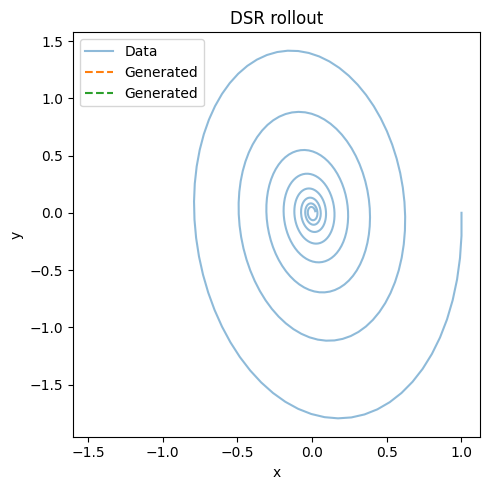

In [5]:
torch.manual_seed(3)
np.random.seed(3)

n_steps = 5000
dt = 0.05
t = np.arange(n_steps) * dt
trajectory = np.zeros((n_steps, 2), dtype=np.float32)
trajectory[0] = [1.0, 0.0]
for i in range(1, n_steps):
    x, y = trajectory[i-1]
    trajectory[i, 0] = x + dt * y
    trajectory[i, 1] = y + dt * (-0.5 * y - 4.0 * x)

ds_dsr = CustomDataset.from_arrays(
    trajectory, mode='timeseries', sequence_length=100, batch_size=16,
    test_fraction=0.2, seed=0
)

cfg_dsr = AutoConfig.for_model(
    'shallow_plrnn', latent_dim=2, hidden_dim=32, output_dim=2,
    autonomous=True
)
model_dsr = AutoModel.from_config(cfg_dsr)

objective_dsr = TeacherForcingObjective(alpha=0.1)
args_dsr = TrainingArguments(
    max_steps=500, learning_rate=1e-3, log_every=100, grad_clip_norm=1.0
)
Trainer(model_dsr, ds_dsr, objective_dsr, args_dsr).train()

# Free rollout from the first validation state
model_dsr.eval()
with torch.no_grad():
    z0 = ds_dsr.test_set.X[0:1]
    gen = model_dsr.generate(z0, n_steps=200).numpy()

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(trajectory[:500, 0], trajectory[:500, 1], alpha=0.5, label='Data')
ax.plot(gen[:, 0], gen[:, 1], '--', label='Generated')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(); ax.set_title('DSR rollout')
plt.tight_layout(); plt.show()


## 5. Behavioral objective

`BehavioralObjective` fits next-action choice behavior. It is a masked cross-entropy objective with special handling for `output_h0=True` models (e.g. `tiny_rnn`).

Here we only show the API on synthetic discrete-choice data.

In [6]:
torch.manual_seed(4)
B, T, K, n_actions = 128, 50, 3, 2
inputs_beh = torch.randn(B, T, K)
targets_beh = torch.randint(0, n_actions, (B, T))
mask_beh = torch.ones(B, T)

ds_beh = SyntheticDataset(inputs_beh, targets_beh, mask_beh, batch_size=32)

cfg_beh = AutoConfig.for_model(
    'ctrnn', input_dim=K, latent_dim=16, output_dim=n_actions, dt=20, tau=100
)
model_beh = AutoModel.from_config(cfg_beh)

objective_beh = BehavioralObjective()
args_beh = TrainingArguments(
    max_steps=200, learning_rate=1e-2, log_every=50, grad_clip_norm=1.0
)
Trainer(model_beh, ds_beh, objective_beh, args_beh).train()

model_beh.eval()
with torch.no_grad():
    out = model_beh(inputs_beh)
    acc = accuracy_classification(out.outputs, targets_beh, mask_beh)
print(f'Behavioral choice accuracy: {acc:.4f}')

[train] step=0  loss=0.7037  nll=0.7037


[train] step=50  loss=0.6924  nll=0.6924


[train] step=100  loss=0.6909  nll=0.6909


[train] step=150  loss=0.6904  nll=0.6904


Behavioral choice accuracy: 0.5292


## 6. Reusable loss terms, regularizers, and metrics

All built-in objectives delegate to functions in `neuralrnn.train.losses`. You can use these same functions when writing custom objectives.

In [7]:
B, T, O = 8, 12, 2
out = torch.randn(B, T, O)
tgt = torch.randn(B, T, O)
mask = torch.ones(B, T, 1)

print('masked_mse:', masked_mse(out, tgt, mask).item())
print('masked_cross_entropy:', masked_cross_entropy(
    torch.randn(B, T, 3), torch.randint(0, 3, (B, T))
).item())

states = torch.randn(B, T, O)
print('activity_l2:', activity_l2(states, mask).item())
print('weight_l2:', weight_l2(model_reg, patterns=['h2h', 'input2h']).item())
print('accuracy_general:', accuracy_general(out, tgt, mask).item())

masked_mse: 3.566664695739746
masked_cross_entropy: 1.4420905113220215
activity_l2: 1.0775376558303833
weight_l2: 0.030074868351221085
accuracy_general: 0.375


## 7. The `build_objective` factory

Objectives are registered by name. This mirrors `AutoConfig` / `AutoModel` and lets you instantiate objectives from strings (e.g. in config files).

In [8]:
obj1 = build_objective('supervised', task_type='classification')
obj2 = build_objective('regularized_supervised', task_type='regression', activity_weight=1e-4)
obj3 = build_objective('teacher_forcing', alpha=0.1)
print(obj1, obj2, obj3, sep='\n')

## 8. Writing a custom objective

The minimal contract is `compute_loss(model, batch)`. Below we implement an objective that combines a task loss with an L2 activity penalty and a weight-decay term, but only on recurrent weights.

In [9]:
from neuralrnn.train.objectives.base import Objective
from neuralrnn.train.losses import masked_mse, activity_l2, weight_l2

class RecurrentRegularizedObjective(Objective):
    """Task MSE + L2 activity + L2 recurrent weight penalty."""

    def __init__(self, activity_weight=1e-4, weight_weight=1e-5):
        self.activity_weight = activity_weight
        self.weight_weight = weight_weight

    def compute_loss(self, model, batch):
        out = model(batch['inputs'])
        task_loss = masked_mse(out.outputs, batch['targets'], batch.get('mask'))
        reg = activity_l2(out.states, batch.get('mask'))
        wreg = weight_l2(model, patterns=['h2h.weight'])
        loss = task_loss + self.activity_weight * reg + self.weight_weight * wreg
        return loss, {
            'loss': loss.item(),
            'task': task_loss.item(),
            'activity': reg.item(),
            'weight': wreg.item(),
        }

torch.manual_seed(5)
model_custom = AutoModel.from_config(cfg_reg)
args_custom = TrainingArguments(
    max_steps=200, learning_rate=1e-2, log_every=50, grad_clip_norm=1.0
)
Trainer(model_custom, ds_reg, RecurrentRegularizedObjective(), args_custom).train()

model_custom.eval()
with torch.no_grad():
    out = model_custom(inputs_reg)
    mse = masked_mse(out.outputs, targets_reg, mask_reg)
print(f'Custom objective MSE: {mse:.4f}')

[train] step=0  loss=0.1211  task=0.1211  activity=0.1071  weight=0.0107


[train] step=50  loss=0.0118  task=0.0118  activity=0.1176  weight=0.0164


[train] step=100  loss=0.0112  task=0.0112  activity=0.1366  weight=0.0166


[train] step=150  loss=0.0106  task=0.0106  activity=0.1247  weight=0.0169


Custom objective MSE: 0.0109


### 8.1 Registering the custom objective

Use `@register_objective` so it becomes available through `build_objective`.

In [10]:
@register_objective('recurrent_regularized')
class RegisteredRecurrentRegularizedObjective(RecurrentRegularizedObjective):
    pass

print('recurrent_regularized' in OBJECTIVE_REGISTRY)
obj_custom = build_objective('recurrent_regularized', activity_weight=1e-3)
print(obj_custom)

True


## 9. Summary

| Concept | API | Use when |
|---|---|---|
| Classification | `SupervisedObjective('classification')` | Discrete choice tasks |
| Regression | `SupervisedObjective('regression')` | Continuous outputs |
| Regularized task | `RegularizedSupervisedObjective(...)` | Task + activity/weight/ortho penalties |
| Dynamics reconstruction | `TeacherForcingObjective(alpha=0.1)` | Reconstruct neural/behavioral trajectories |
| Behavioral fitting | `BehavioralObjective()` | Next-choice NLL |
| Custom | subclass `Objective` + `compute_loss` | Anything else |

Key takeaways:

1. `Trainer` is paradigm-agnostic; the objective decides the paradigm.
2. Reusable loss terms live in `neuralrnn.train.losses`.
3. Use `build_objective` / `register_objective` for config-driven training.
4. Custom objectives only need to implement `compute_loss(model, batch)`.